In [1]:
%pip install seaborn

/Users/anandkashyap/Documents/GitHub/gaze_vit_v2/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import sklearn
import cv2
import os 
import numpy as np
import seaborn as sns

In [2]:
predictions = np.random.randint(0, 10, (100,)) 
targets = np.random.randint(0, 10, (100,)) 

<class 'numpy.ndarray'>


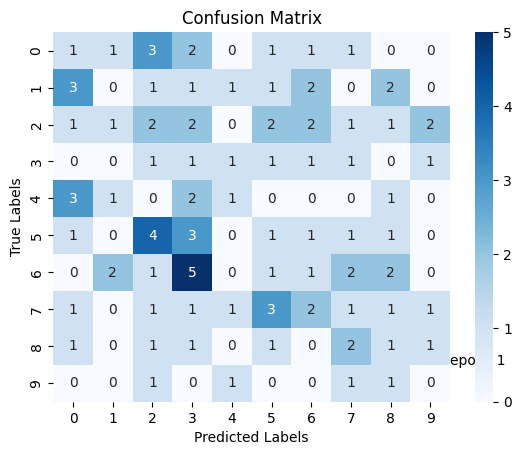

In [22]:
confusion_matrices = []
size = (0,0)

def append_confusion_matrix(predictions, targets, epoch):

    matrix = sklearn.metrics.confusion_matrix(targets, predictions)
    size = matrix.shape
    img = sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
    img.set_title('Confusion Matrix')
    img.set_xlabel('Predicted Labels')
    img.set_ylabel('True Labels')  
    img.text(10, 9, f"epoch {epoch}") #cooked sry
    fig = img.get_figure()
    fig.canvas.draw()
    ## idk what these next three lines do. claude locked in
    buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
    frame = buf.reshape(fig.canvas.get_width_height()[::-1] + (4,))
    frame = frame[:, :, :3] 

    confusion_matrices.append(frame)

append_confusion_matrix(predictions, targets, 1)
print(type(confusion_matrices[0]))

In [23]:
def create_video(fps=2):
    writer = cv2.VideoWriter('confusion_matrices.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, size)
    # make it from rgb to bgr
    for matrix in confusion_matrices:
        switched_matrix = cv2.cvtColor(matrix, cv2.COLOR_RGB2BGR)
        writer.write(switched_matrix)
    writer.release()

In [24]:
create_video()